# Output Token Style Test
Tests which response style instruction produces the fewest **output** tokens across models.
Same question, same model — only the style instruction varies.
Output tokens are what cost most (typically 4-8x input price).

In [1]:
import json, os, time
import pandas as pd
import requests
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("OPENROUTER_API_KEY")
BASE_URL = "https://openrouter.ai/api/v1/chat/completions"

assert API_KEY, "OPENROUTER_API_KEY not set — add it to .env"

MODELS = {
    "qwen3-8b":     "qwen/qwen3-8b",
    "gpt-oss-20b":  "openai/gpt-oss-20b",
    "gpt-oss-120b": "openai/gpt-oss-120b",
    "qwen3.6-35b":  "qwen/qwen3.6-35b-a3b",
    "llama-3.3-70b":"meta-llama/llama-3.3-70b-instruct",
    "gemma4-26b":   "google/gemma-4-26b-a4b-it",
}

def fetch_model_prices(model_id: str) -> dict:
    try:
        r = requests.get(
            "https://openrouter.ai/api/v1/models",
            headers={"Authorization": f"Bearer {API_KEY}"},
            timeout=10,
        )
        r.raise_for_status()
        for m in r.json().get("data", []):
            if m["id"] == model_id:
                pricing = m.get("pricing", {})
                return {
                    "input":  float(pricing.get("prompt", 0)),
                    "output": float(pricing.get("completion", 0)),
                }
    except Exception as e:
        print(f"Warning: could not fetch pricing — {e}")
    return {"input": 0.0, "output": 0.0}

def split_cost(tokens_in, tokens_out, prices, actual_total=None):
    p_in, p_out = prices["input"], prices["output"]
    if p_in == 0 and p_out == 0:
        return None, None
    w_in  = tokens_in  * p_in  if tokens_in  > 0 else 0.0
    w_out = tokens_out * p_out if tokens_out > 0 else 0.0
    total_w = w_in + w_out
    if total_w == 0:
        return None, None
    if actual_total is not None and actual_total > 0:
        return actual_total * w_in / total_w, actual_total * w_out / total_w
    return w_in, w_out

print("Fetching model prices...")
MODEL_PRICES = {name: fetch_model_prices(mid) for name, mid in MODELS.items()}
print(f"{'Model':<20} {'Input/1M':>10} {'Output/1M':>10}")
print("-" * 42)
for name, p in MODEL_PRICES.items():
    print(f"  {name:<18} ${p['input']*1e6:>8.4f}  ${p['output']*1e6:>8.4f}")
print(f"\nAPI key: {API_KEY[:8]}...")


Fetching model prices...
Model                  Input/1M  Output/1M
------------------------------------------
  qwen3-8b           $  0.0500  $  0.4000
  gpt-oss-20b        $  0.0300  $  0.1400
  gpt-oss-120b       $  0.0390  $  0.1800
  qwen3.6-35b        $  0.1612  $  0.9652
  llama-3.3-70b      $  0.1000  $  0.3200
  gemma4-26b         $  0.0600  $  0.3300

API key: sk-or-v1...


In [2]:
# Style instructions — same question, different response style prefix
# Baseline has no instruction so we see the model's natural verbosity

STYLES = {
    "baseline":    "",
    "caveman":     "Talk like caveman. Short words. No filler. No full sentences.",
    "telegraph":   "Telegraph style: bullets only, no preamble, no summary, drop articles, abbreviate (fn/cfg/db/auth/impl/req/res/err), arrows for cause→effect, answer immediately, no hedging.",
    "minimal":     "Be maximally concise. No preamble. No trailing summary. No restating the question. Answer only.",
    "structured":  "Reply format: ANSWER: <one line> | STEPS: <numbered, terse> | CODE: <only if needed> — nothing else outside this format.",
    "bullets":     "Respond in bullet points only. No prose. No intro. No outro. Each bullet max 10 words.",
    "ultrashort":  "One sentence answers only. If code needed, code only, no explanation.",
    "yoda":        "Respond like Yoda. Inverted syntax. Same words, rearranged. No extra words added.",
}

# Questions that generate varied-length responses — mix of explanation, code, reasoning
TEST_QUESTIONS = {
    "jwt_auth":     "Explain how JWT authentication works and show a Python example.",
    "sql_explain":  "What is a database index and when should you use one?",
    "debug_task":   "My Python function returns None unexpectedly. What are the most common causes?",
    "design_q":     "What is the difference between REST and GraphQL?",
    "simple_code":  "Write a Python function that checks if a string is a palindrome.",
}

print(f"Styles   : {len(STYLES)}")
print(f"Questions: {len(TEST_QUESTIONS)}")
print(f"Models   : {len(MODELS)}")
print(f"Total API calls: {len(STYLES) * len(TEST_QUESTIONS) * len(MODELS)}")
print()
for name, instruction in STYLES.items():
    preview = instruction[:60] + "..." if len(instruction) > 60 else instruction or "(none)"
    print(f"  {name:<12} → {preview}")


Styles   : 8
Questions: 5
Models   : 6
Total API calls: 240

  baseline     → (none)
  caveman      → Talk like caveman. Short words. No filler. No full sentences...
  telegraph    → Telegraph style: bullets only, no preamble, no summary, drop...
  minimal      → Be maximally concise. No preamble. No trailing summary. No r...
  structured   → Reply format: ANSWER: <one line> | STEPS: <numbered, terse> ...
  bullets      → Respond in bullet points only. No prose. No intro. No outro....
  ultrashort   → One sentence answers only. If code needed, code only, no exp...
  yoda         → Respond like Yoda. Inverted syntax. Same words, rearranged. ...


In [3]:
def send_style_test(question_name, question, style_name, style_instruction, model_name, model_id, delay=0.5):
    """Send a question with a style instruction, return full token + cost breakdown."""
    time.sleep(delay)
    content = f"{style_instruction}\n\n{question}" if style_instruction else question
    payload = {
        "model": model_id,
        "messages": [{"role": "user", "content": content}],
        "max_tokens": 1024,  # generous — we want to see natural response length
    }
    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json",
        "HTTP-Referer": "https://github.com/moxy",
    }
    try:
        t0 = time.time()
        r = requests.post(BASE_URL, json=payload, headers=headers, timeout=60)
        latency_ms = int((time.time() - t0) * 1000)
        r.raise_for_status()
        data = r.json()
        usage = data.get("usage", {})
        reply = data["choices"][0]["message"]["content"] if data.get("choices") else ""
        tokens_in  = usage.get("prompt_tokens", -1)
        tokens_out = usage.get("completion_tokens", -1)
        cost_total = usage.get("cost", None)
        prices = MODEL_PRICES.get(model_name, {"input": 0.0, "output": 0.0})
        cost_in, cost_out = split_cost(tokens_in, tokens_out, prices, actual_total=cost_total)
        return {
            "model": model_name,
            "question": question_name,
            "style": style_name,
            "tokens_in": tokens_in,
            "tokens_out": tokens_out,
            "cost_in_usd": cost_in,
            "cost_out_usd": cost_out,
            "cost_usd": cost_total,
            "response_preview": reply[:150].replace("\n", " "),
            "latency_ms": latency_ms,
        }
    except Exception as e:
        return {
            "model": model_name, "question": question_name, "style": style_name,
            "tokens_in": -1, "tokens_out": -1,
            "cost_in_usd": None, "cost_out_usd": None, "cost_usd": None,
            "response_preview": f"ERROR: {e}",
            "latency_ms": -1,
        }


In [4]:
results = []
total = len(MODELS) * len(TEST_QUESTIONS) * len(STYLES)
n = 0
def fmt(v): return f"${v:.6f}" if v is not None else "  n/a  "

for model_name, model_id in MODELS.items():
    print(f"\n{'═'*60}")
    print(f"  {model_name}")
    print(f"{'═'*60}")
    for q_name, question in TEST_QUESTIONS.items():
        print(f"  ── {q_name} ──")
        for style_name, style_instruction in STYLES.items():
            n += 1
            r = send_style_test(q_name, question, style_name, style_instruction, model_name, model_id)
            results.append(r)
            tag = style_name[:10].ljust(10)
            print(f"    [{n:>3}/{total}] {tag}  in={r['tokens_in']:>4}  out={r['tokens_out']:>4}  "
                  f"$in={fmt(r['cost_in_usd'])}  $out={fmt(r['cost_out_usd'])}  $tot={fmt(r['cost_usd'])}")

df = pd.DataFrame(results)
df.to_csv("output_style_results.csv", index=False)
print(f"\n{'─'*60}")
print(f"Done. Total cost: {fmt(df['cost_usd'].sum())}  |  Saved to output_style_results.csv")



════════════════════════════════════════════════════════════
  qwen3-8b
════════════════════════════════════════════════════════════
  ── jwt_auth ──
    [  1/240] baseline    in=  20  out=3078  $in=$0.000001  $out=$0.001402  $tot=$0.001403
    [  2/240] caveman     in=  35  out= 638  $in=$0.000002  $out=$0.000292  $tot=$0.000294
    [  3/240] telegraph   in=  65  out= 678  $in=$0.000003  $out=$0.000271  $tot=$0.000274
    [  4/240] minimal     in=  41  out= 794  $in=$0.000002  $out=$0.000364  $tot=$0.000366
    [  5/240] structured  in=  55  out= 762  $in=$0.000003  $out=$0.000305  $tot=$0.000308
    [  6/240] bullets     in=  43  out= 995  $in=$0.000002  $out=$0.000455  $tot=$0.000458
    [  7/240] ultrashort  in=  35  out= 431  $in=$0.000002  $out=$0.000172  $tot=$0.000174
    [  8/240] yoda        in=  40  out=1183  $in=$0.000002  $out=$0.000473  $tot=$0.000475
  ── sql_explain ──
    [  9/240] baseline    in=  20  out=1525  $in=$0.000001  $out=$0.000695  $tot=$0.000696
    [ 10/2

In [6]:
# Summary: avg output tokens per style, across all models and questions
valid = df[df["tokens_out"] > 0]

print("=" * 65)
print("OUTPUT TOKEN REDUCTION vs BASELINE")
print("=" * 65)

baseline_avg = valid[valid["style"] == "baseline"].groupby("model")["tokens_out"].mean()
style_avg = valid.groupby(["model", "style"])["tokens_out"].mean().unstack()

# Reduction table
reduction = pd.DataFrame()
for style in STYLES.keys():
    if style in style_avg.columns:
        reduction[style] = ((baseline_avg - style_avg[style]) / baseline_avg * 100).round(1)

print("\n% reduction in output tokens vs baseline (positive = fewer tokens):")
display(reduction)

# Overall winner per model
print("\nBest style per model (most output token reduction):")
for model in MODELS.keys():
    if model in reduction.index:
        best = reduction.loc[model].drop("baseline", errors="ignore").idxmax()
        pct  = reduction.loc[model][best]
        print(f"  {model:<20} → {best:<12} ({pct:+.1f}%)")

# Overall winner across all models
overall = reduction.drop(columns="baseline", errors="ignore").mean().sort_values(ascending=False)
print(f"\nOverall best style (avg across all models): {overall.index[0]} ({overall.iloc[0]:+.1f}%)")
print("\nFull ranking:")
for style, pct in overall.items():
    bar = "█" * max(0, int(pct / 2))
    print(f"  {style:<12} {pct:>+6.1f}%  {bar}")


OUTPUT TOKEN REDUCTION vs BASELINE

% reduction in output tokens vs baseline (positive = fewer tokens):


,baseline,caveman,telegraph,minimal,structured,bullets,ultrashort,yoda
model,,,,,,,,
gemma4-26b,0.0,87.3,78.2,85.9,81.9,84.7,92.7,94.6
gpt-oss-120b,0.0,71.7,45.1,69.4,64.1,41.9,85.9,2.5
gpt-oss-20b,0.0,52.1,31.9,76.9,51.4,48.1,71.9,16.3
llama-3.3-70b,0.0,94.3,79.1,80.5,80.7,92.2,91.8,86.4
qwen3-8b,0.0,76.5,67.0,74.8,76.7,73.0,80.3,65.9
qwen3.6-35b,0.0,27.7,20.5,36.3,35.7,46.4,57.3,41.3



Best style per model (most output token reduction):
  qwen3-8b             → ultrashort   (+80.3%)
  gpt-oss-20b          → minimal      (+76.9%)
  gpt-oss-120b         → ultrashort   (+85.9%)
  qwen3.6-35b          → ultrashort   (+57.3%)
  llama-3.3-70b        → caveman      (+94.3%)
  gemma4-26b           → yoda         (+94.6%)

Overall best style (avg across all models): ultrashort (+80.0%)

Full ranking:
  ultrashort    +80.0%  ███████████████████████████████████████
  minimal       +70.6%  ███████████████████████████████████
  caveman       +68.3%  ██████████████████████████████████
  structured    +65.1%  ████████████████████████████████
  bullets       +64.4%  ████████████████████████████████
  telegraph     +53.6%  ██████████████████████████
  yoda          +51.2%  █████████████████████████


In [8]:
# Cost savings: how much cheaper is each style vs baseline?
print("=" * 65)
print("COST SAVINGS vs BASELINE")
print("=" * 65)

cost_avg = valid.groupby(["model", "style"])["cost_usd"].mean().unstack()
baseline_cost = valid[valid["style"] == "baseline"].groupby("model")["cost_usd"].mean()

cost_reduction = pd.DataFrame()
for style in STYLES.keys():
    if style in cost_avg.columns:
        cost_reduction[style] = ((baseline_cost - cost_avg[style]) / baseline_cost * 100).round(1)

print("\n% cost reduction vs baseline (positive = cheaper):")
display(cost_reduction)

overall_cost = cost_reduction.drop(columns="baseline", errors="ignore").mean().sort_values(ascending=False)
print(f"\nCheapest style overall: {overall_cost.index[0]} ({overall_cost.iloc[0]:+.1f}%)")


COST SAVINGS vs BASELINE

% cost reduction vs baseline (positive = cheaper):


,baseline,caveman,telegraph,minimal,structured,bullets,ultrashort,yoda
model,,,,,,,,
gemma4-26b,0.0,86.7,70.4,84.1,81.2,82.6,91.4,89.8
gpt-oss-120b,0.0,77.5,75.7,86.2,64.0,51.1,86.2,37.2
gpt-oss-20b,0.0,59.7,42.6,76.4,62.0,51.3,74.8,2.4
llama-3.3-70b,0.0,96.0,87.7,89.6,89.0,91.6,88.4,91.0
qwen3-8b,0.0,76.4,65.7,75.0,77.8,72.5,80.6,67.7
qwen3.6-35b,0.0,27.5,20.0,36.1,35.3,39.5,57.0,41.0



Cheapest style overall: ultrashort (+79.7%)


In [9]:
# Per-question breakdown: which style wins for each question type?
print("=" * 65)
print("BEST STYLE PER QUESTION TYPE (avg across all models)")
print("=" * 65)

q_style = valid.groupby(["question", "style"])["tokens_out"].mean().unstack()
for q in TEST_QUESTIONS.keys():
    if q in q_style.index:
        row = q_style.loc[q]
        baseline_val = row.get("baseline", row.max())
        best_style = row.drop("baseline", errors="ignore").idxmin()
        best_val = row[best_style]
        saving = (baseline_val - best_val) / baseline_val * 100
        print(f"  {q:<15} baseline={baseline_val:>5.0f} tok  best={best_style:<12} ({best_val:>5.0f} tok, -{saving:.0f}%)")


BEST STYLE PER QUESTION TYPE (avg across all models)
  jwt_auth        baseline= 1379 tok  best=caveman      (  450 tok, -67%)
  sql_explain     baseline= 1026 tok  best=ultrashort   (  207 tok, -80%)
  debug_task      baseline= 1316 tok  best=ultrashort   (  170 tok, -87%)
  design_q        baseline= 1218 tok  best=ultrashort   (  203 tok, -83%)
  simple_code     baseline=  853 tok  best=minimal      (  278 tok, -67%)


pip install plotly for interactive charts


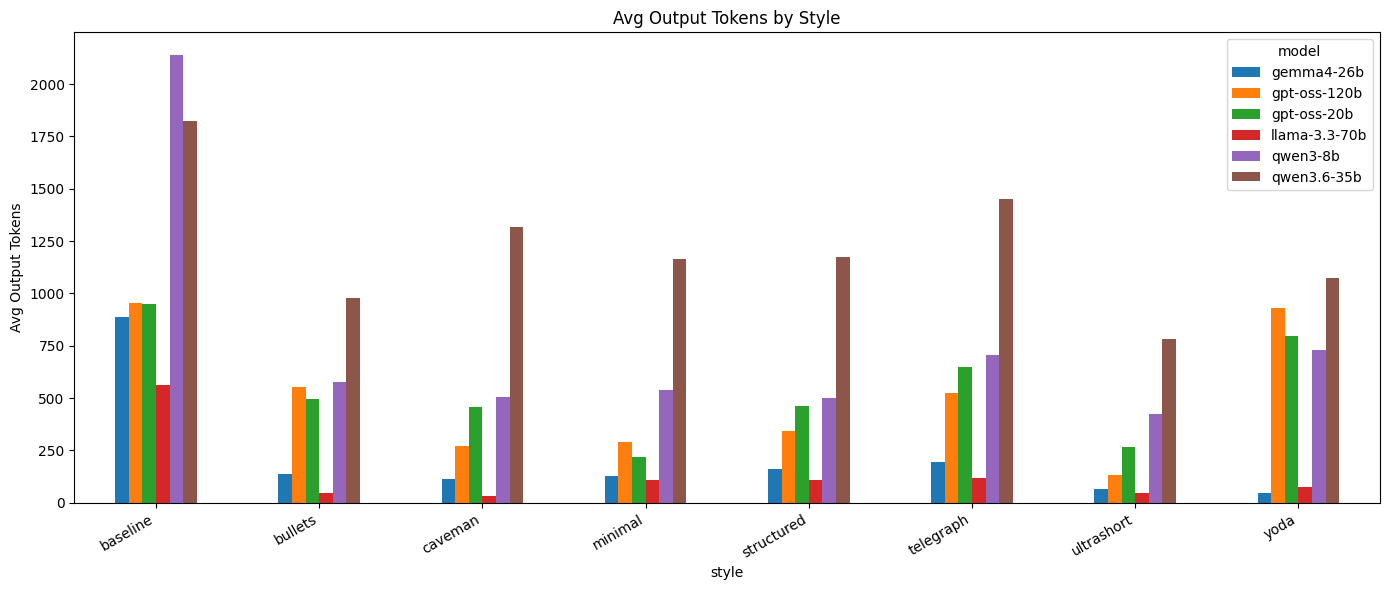

In [10]:
# Plotly visualization
try:
    import plotly.express as px
    import plotly.graph_objects as go
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False
    print("pip install plotly for interactive charts")

if HAS_PLOTLY:
    # Avg output tokens: style × model grouped bar
    avg_out = valid.groupby(["style", "model"])["tokens_out"].mean().reset_index()
    fig1 = px.bar(
        avg_out, x="style", y="tokens_out", color="model", barmode="group",
        title="Avg Output Tokens by Style — All Models",
        labels={"tokens_out": "Avg Output Tokens", "style": "Style", "model": "Model"},
        template="plotly_dark", height=500,
    )
    fig1.update_layout(xaxis_categoryorder="total ascending")
    fig1.write_html("output_style_bar.html")
    fig1.show()

    # Heatmap: style × model, avg output tokens
    hm = valid.groupby(["style", "model"])["tokens_out"].mean().unstack()
    hm["_avg"] = hm.mean(axis=1)
    hm = hm.sort_values("_avg").drop(columns="_avg")
    fig2 = go.Figure(data=go.Heatmap(
        z=hm.values, x=hm.columns.tolist(), y=hm.index.tolist(),
        colorscale="RdYlGn_r",
        text=[[f"{v:.0f}" for v in row] for row in hm.values],
        texttemplate="%{text}", textfont={"size": 11},
    ))
    fig2.update_layout(
        title="Output Token Heatmap — Style × Model (lower = better)",
        xaxis_title="Model", yaxis_title="Style",
        template="plotly_dark", height=420,
    )
    fig2.write_html("output_style_heatmap.html")
    fig2.show()

    # Cost heatmap
    cost_hm = valid.groupby(["style", "model"])["cost_usd"].mean().unstack()
    cost_hm["_avg"] = cost_hm.mean(axis=1)
    cost_hm = cost_hm.sort_values("_avg").drop(columns="_avg")
    fig3 = go.Figure(data=go.Heatmap(
        z=cost_hm.values, x=cost_hm.columns.tolist(), y=cost_hm.index.tolist(),
        colorscale="Reds",
        text=[[f"${v:.5f}" for v in row] for row in cost_hm.values],
        texttemplate="%{text}", textfont={"size": 9},
    ))
    fig3.update_layout(
        title="Cost Heatmap (USD) — Style × Model (lower = better)",
        xaxis_title="Model", yaxis_title="Style",
        template="plotly_dark", height=420,
    )
    fig3.write_html("output_style_cost_heatmap.html")
    fig3.show()

    print("Saved: output_style_bar.html, output_style_heatmap.html, output_style_cost_heatmap.html")

else:
    import matplotlib.pyplot as plt
    import numpy as np
    avg_out = valid.groupby(["style", "model"])["tokens_out"].mean().unstack()
    avg_out.plot(kind="bar", figsize=(14, 6))
    plt.title("Avg Output Tokens by Style")
    plt.ylabel("Avg Output Tokens")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("output_style_bar.png", dpi=150)
    plt.show()


In [11]:
# Sample responses — see what each style actually produces for one question
PREVIEW_QUESTION = "jwt_auth"
PREVIEW_MODEL    = list(MODELS.keys())[0]

print(f"Response previews — question: {PREVIEW_QUESTION}, model: {PREVIEW_MODEL}")
print("=" * 65)

subset = df[(df["question"] == PREVIEW_QUESTION) & (df["model"] == PREVIEW_MODEL)]
for _, row in subset.sort_values("tokens_out").iterrows():
    print(f"\n[{row['style']:<12}] out={row['tokens_out']:>4} tokens")
    print(f"  {row['response_preview']}")


Response previews — question: jwt_auth, model: qwen3-8b

[ultrashort  ] out= 431 tokens
  JWT authentication works by generating a signed token containing user claims, which is sent to the client and validated by the server on subsequent re

[caveman     ] out= 638 tokens
  JWT is token. When user login, server make token. Token has 3 parts: header, payload, signature. Header says what is inside. Payload has user data. Si

[telegraph   ] out= 678 tokens
  - client sends req with credentials → server checks db (auth)   - server generates jwt (impl) with header, payload, signature (cfg)   - jwt contains u

[structured  ] out= 762 tokens
  ANSWER: JWT authentication uses a token containing user data and a signature to authenticate requests.   STEPS:   1. User authenticates, server verifi

[minimal     ] out= 794 tokens
  JWT (JSON Web Token) authentication involves three steps:   1. **Token Generation**: The server creates a token with user claims (e.g., user ID) and s

[bullets     ] out